Loaded samples: 12000
Classes found: {'feeding', 'background', 'post-feeding', 'pre-feeding'}

--- SVM RESULTS (1-second segments) ---
Training time: 287.5183 s
Inference time per sample: 7.5587 ms
Accuracy: 0.9958
Precision: 0.9881
Recall: 0.9927
F1-score: 0.9903
ROC-AUC: 0.9999911458333333

Confusion Matrix (raw counts):
 [[ 180    0    0    0]
 [   0  147    0    3]
 [   0    5  625    0]
 [   0    2    0 1438]]


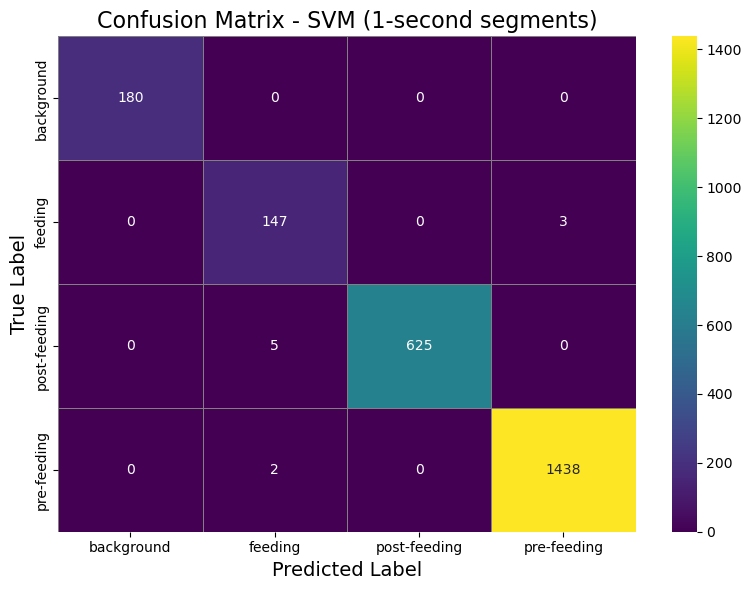

In [1]:
import os
import time
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from sklearn.model_selection import train_test_split


# ---------------------------------------------------------
# CONFIG
# ---------------------------------------------------------
DATASET_PATH = "/home/feliciano/Documents/DATASET_SEABREAM_SEGMENTED/Segmented_2s"
SAMPLE_RATE = 8000
N_MELS = 128


# ---------------------------------------------------------
# FEATURE EXTRACTION
# ---------------------------------------------------------
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

    # Log-Mel Spectrogram
    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, fmax=1000
    )
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Spectral Contrast
    contrast = librosa.feature.spectral_contrast(
        y=y, sr=sr, fmin=50, n_bands=6
    )

    # Flatten and concatenate
    features = np.concatenate([
        mel_db.flatten(),
        contrast.flatten()
    ])

    return features


# ---------------------------------------------------------
# LABEL MAPPING (THE FIX YOU NEEDED)
# ---------------------------------------------------------
def map_label_from_path(path):
    p = path.lower()

    if "background" in p:
        return "background"

    if "pre" in p and "feed" in p:
        return "pre-feeding"

    if "post" in p and "feed" in p:
        return "post-feeding"

    if "feeding" in p:
        return "feeding"

    return None  # ignore irrelevant folders


# ---------------------------------------------------------
# LOAD DATASET
# ---------------------------------------------------------
X = []
y = []

for root, dirs, files in os.walk(DATASET_PATH):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)

            label = map_label_from_path(root)
            if label is None:
                continue  # skip non-behaviour folders

            features = extract_features(file_path)
            X.append(features)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("Loaded samples:", X.shape[0])
print("Classes found:", set(y))


# ---------------------------------------------------------
# ENCODING + SCALING
# ---------------------------------------------------------
le = LabelEncoder()
y_encoded = le.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ---------------------------------------------------------
# TRAIN/TEST SPLIT
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)


# ---------------------------------------------------------
# TRAIN SVM
# ---------------------------------------------------------
svm = SVC(kernel="rbf", probability=True)

start_train = time.time()
svm.fit(X_train, y_train)
train_time = time.time() - start_train


# ---------------------------------------------------------
# INFERENCE
# ---------------------------------------------------------
start_inf = time.time()
y_pred = svm.predict(X_test)
inf_time = (time.time() - start_inf) / len(X_test)

y_prob = svm.predict_proba(X_test)


# ---------------------------------------------------------
# METRICS
# ---------------------------------------------------------
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="macro")
rec = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

try:
    auc = roc_auc_score(y_test, y_prob, multi_class="ovr")
except:
    auc = None

cm = confusion_matrix(y_test, y_pred)


# ---------------------------------------------------------
# PRINT RESULTS
# ---------------------------------------------------------
print("\n--- SVM RESULTS (1-second segments) ---")
print("Training time:", round(train_time, 4), "s")
print("Inference time per sample:", round(inf_time * 1000, 4), "ms")
print("Accuracy:", round(acc, 4))
print("Precision:", round(prec, 4))
print("Recall:", round(rec, 4))
print("F1-score:", round(f1, 4))
print("ROC-AUC:", auc)
print("\nConfusion Matrix (raw counts):\n", cm)


# ---------------------------------------------------------
# BEAUTIFUL CONFUSION MATRIX (4×4)
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    linewidths=0.5,
    linecolor="gray"
)

plt.title("Confusion Matrix - SVM (2-second segments)", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.tight_layout()
plt.show()
